# Implementation for Data Cleaning

Step 1: Import Libraries and Load Dataset

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [69]:
import pandas as pd 
import numpy as np
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Step 2: df.info()

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [71]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Step 2: Check for Duplicate Rows

df.duplicated(): Returns a boolean Series indicating duplicate rows.

In [72]:
df.duplicated().sum()

np.int64(0)

Step 3: Identify Column Data Types

List comprehension with .dtype attribute to separate categorical and numerical columns.

object dtype: Generally used for text or categorical data.

In [73]:
cat_col = df.select_dtypes(include='str').columns
print(cat_col)
num_col = df.select_dtypes(include='number').columns
print(num_col)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


In [74]:
cat_col = [col for col in df.columns if df[col].dtype == 'str']
num_col = [col for col in df.columns if df[col].dtype != 'str']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


Step 4: Count Unique Values in the Categorical Columns

df[cat_col].nunique(): Returns count of unique values per column.

In [75]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

Step 5: Calculate Missing Values as Percentage

df.isnull(): Detects missing values, returning boolean DataFrame.

Sum missing across columns, normalize by total rows and multiply by 100.

In [76]:
round((df.isnull().sum()/df.shape[0])*100,2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Step 6: Drop Irrelevant or Data-Heavy Missing Columns

df.drop(columns=[]): Drops specified columns from the DataFrame.

df.dropna(subset=[]): Removes rows where specified columns have missing values.

fillna(): Fills missing values with specified value (e.g., mean).

In [77]:
df1 = df.drop(columns=['Name','Ticket','Cabin'])

<Axes: xlabel='Embarked', ylabel='count'>

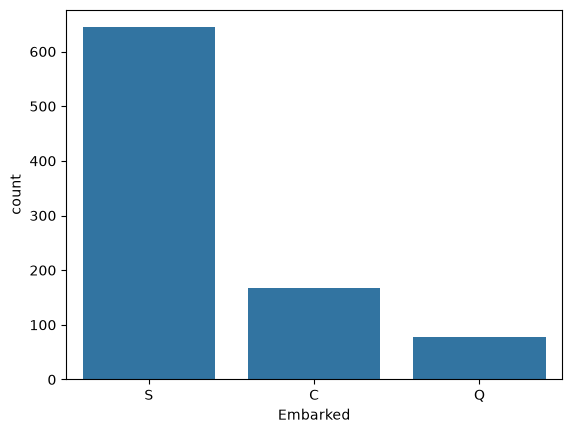

In [78]:
sns.countplot(data=df1,x='Embarked')

In [81]:
df1['Embarked'].fillna(df1['Embarked'].mode(),inplace=True)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

<Axes: xlabel='Age', ylabel='Count'>

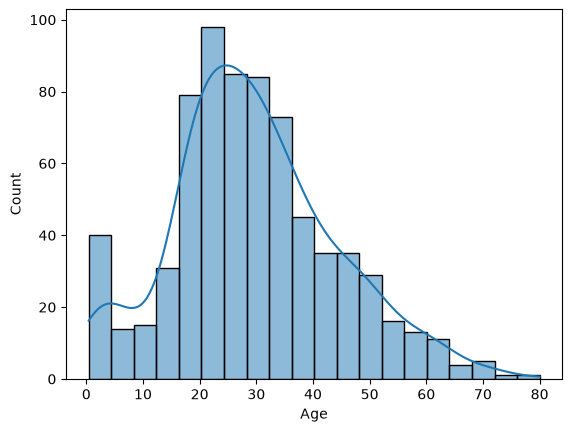

In [61]:
sns.histplot(data=df1['Age'],kde=True)

In [82]:
df1['Age'] = df1['Age'].fillna(df1['Age'].median())

Step 7: Detect Outliers with Box Plot

matplotlib.pyplot.boxplot(): Displays distribution of data, highlighting median, quartiles and outliers.

plt.show(): Renders the plot.

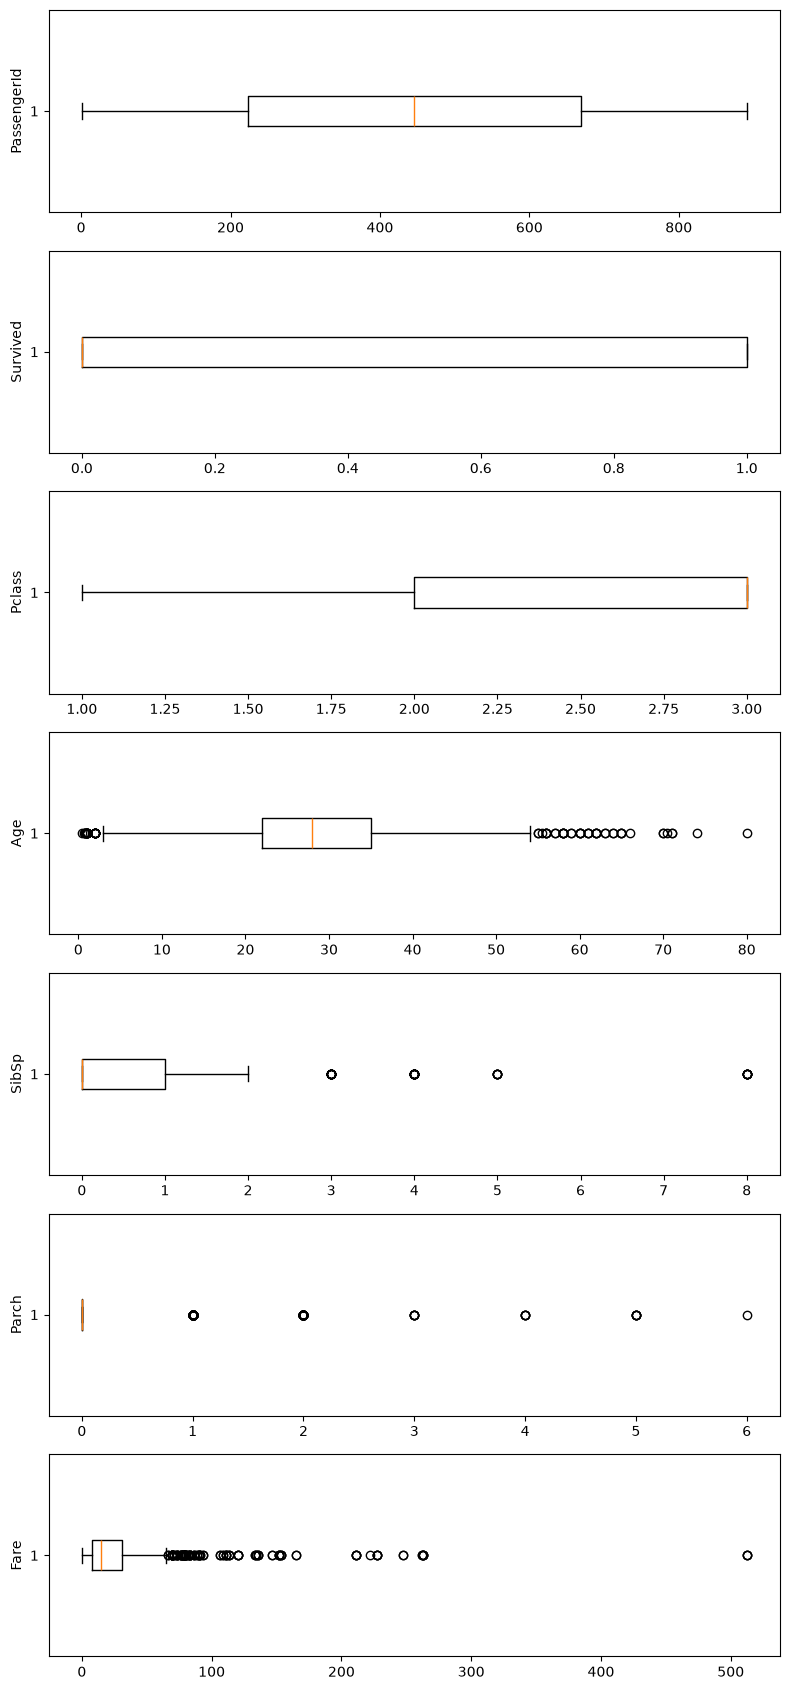

In [89]:
fig,axs = plt.subplots(nrows = len(num_col),ncols=1,figsize=(8,17))

for i,col in enumerate(num_col):
    axs[i].boxplot(df1[col],vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()

Step 8: Calculate Outlier Boundaries and Remove Them

Calculate mean and standard deviation (std) using df['Age'].mean() and df['Age'].std().

Define bounds as mean ± 2 * std for outlier detection.

Filter DataFrame rows within bounds using Boolean indexing.

In [ ]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean -2*std
upper_bound = mean +2*std

df2 = df1[(df1['Age']>=lower_bound) & (df1['Age']<=upper_bound)]

In [93]:
df2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       1
dtype: int64

In [97]:
df2.dropna(subset=['Embarked'],inplace=True)

In [98]:
df2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Step 9: Impute Missing Data Again if Any

fillna() applied again on filtered data to handle any remaining missing values.

In [99]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data

mean = df3['Age'].mean(): Calculates the average (mean) value of the Age column in the DataFrame df3.

std = df3['Age'].std(): Computes the standard deviation (spread or variability) of the Age column in df3.

lower_bound = mean - 2 * std: Defines the lower limit for acceptable Age values, set as two standard deviations below the mean.

upper_bound = mean + 2 * std: Defines the upper limit for acceptable Age values, set as two standard deviations above the mean.

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]: Creates a new DataFrame df4 by selecting only rows where the Age value 
falls between the lower and upper bounds, effectively removing outlier ages outside this range.

In [100]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.656617535927275
Upper Bound : 48.8531385616337


Step 11: Data validation and verification

Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge. 

For the machine learning prediction we separate independent and target features

Here we will consider 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', and 'Embarked' as independent features.

Survived as target variables because PassengerId will not affect the survival rate

In [101]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

Step 12: Data formatting

Data formatting involves converting the data into a standard format or structure that can be easily processed by the algorithms or models used for analysis. Here we will discuss commonly used data formatting techniques i.e. Scaling and Normalization.

1. Min-Max Scaling:
   Scaling involves transforming the values of features to a specific range. Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.

In [103]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

num_col_ = [col for col in X.columns if X[col].dtype != 'str']
x1=X
x1[num_col_]=scaler.fit_transform(x1[num_col_])
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.352941,0.125,0.0,0.014151,S
1,0.0,female,0.666667,0.125,0.0,0.139136,C
2,1.0,female,0.431373,0.000,0.0,0.015469,S
3,0.0,female,0.607843,0.125,0.0,0.103644,S
4,1.0,male,0.607843,0.000,0.0,0.015713,S


2. Standardization (Z-score scaling): 
   Standardization transforms the values to have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it based on the standard deviation. Standardization makes the data more suitable for algorithms that assume a Gaussian distribution or require features to have zero mean and unit variance.

Z = (X - μ) / σ

Where,

X = Data

μ = Mean value of X

σ = Standard deviation of X